In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
]) * V_arr

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total

temps_num = len(temps)
V_num = len(V_arr)

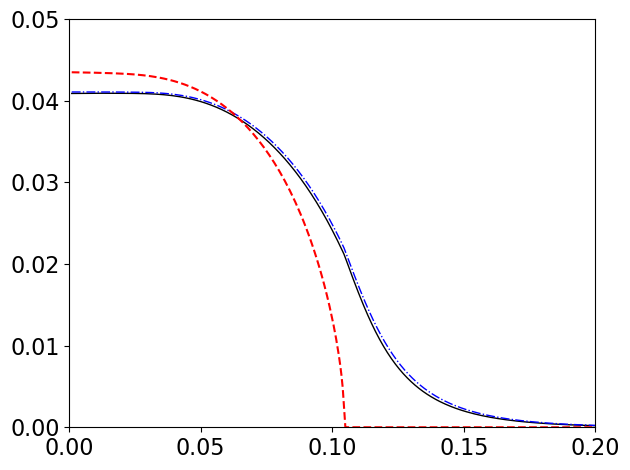

(0.30643105944180643+0j)


In [4]:
df_part = np.load('./data/SFP_part.npz')
df_sc = np.load('./data/SFP_sc.npz')

temps = df_sc["temps"]
F0 = df_sc["F0"]
F_px_sc = df_sc["F_px"]
F_py_sc = df_sc["F_py"]
F_px_part = df_part["F_px"]
F_py_part = df_part["F_py"]

plt.figure(1)
plt.clf()

plt.plot(temps, np.abs(F_px_sc), linewidth=1, label=r"SC S: $p_x$", color='black')
plt.plot(temps, np.abs(F_px_part), "-.", linewidth=1, label=r"Non-SC S: $p_x$", color='blue')
plt.plot(temps, np.abs(F_py_sc), "--", label=r"Both: $p_y$", color='red')

plt.ylim(0,0.05)
plt.xlim(0,0.2)
# plt.xlabel("T", fontsize=15)
# plt.legend(loc="best", fontsize=15)
plt.xticks([0, 0.05, 0.10, 0.15, 0.20 ],fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("../../figures/SFP_U325_sc_nsc.svg", bbox_inches="tight")
plt.show()
print(F0[0])


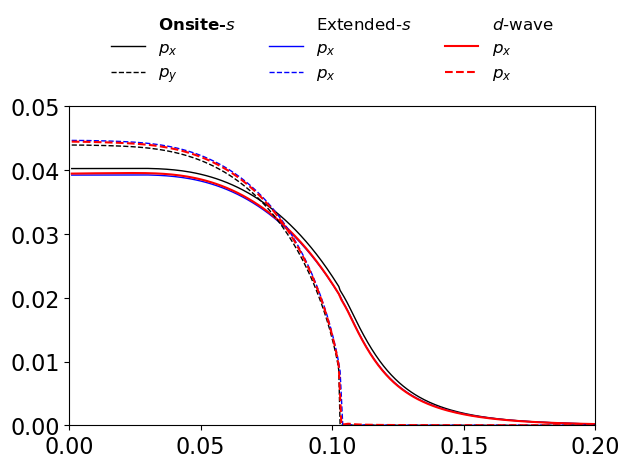

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle

df_ext = np.load('./data/SFP_ext.npz')
df_ons = np.load('./data/SFP_ons.npz')
df_dfp = np.load('./data/DFP.npz')
temps_ext = df_ext["temps"]
temps_ons = df_ons["temps"]
temps_dfp = df_dfp["temps"]
px_ext = (df_ext["Fuu_px"] - df_ext["Fdd_px"]) / 2
px_ons = (df_ons["Fuu_px"] - df_ons["Fdd_px"]) / 2
px_dfp = (df_dfp["Fuu_px"] - df_dfp["Fdd_px"]) / 2
py_ext = (df_ext["Fuu_py"] + df_ext["Fdd_py"]) / 2
py_ons = (df_ons["Fuu_py"] + df_ons["Fdd_py"]) / 2
py_dfp = (df_dfp["Fuu_py"] + df_dfp["Fdd_py"]) / 2

fig, ax = plt.subplots(num=1)
ax.cla()

p1, = ax.plot(temps_ons, np.abs(px_ons), linewidth=1, color='black')
p2, = ax.plot(temps_ext, np.abs(px_ext), linewidth=1, color='blue')
p3, = ax.plot(temps_dfp, np.abs(px_dfp), color='red')
p4, = ax.plot(temps_ons, np.abs(py_ons), "--", linewidth=1, color='black')
p5, = ax.plot(temps_ext, np.abs(py_ext), "--", linewidth=1, color='blue')
p6, = ax.plot(temps_dfp, np.abs(py_dfp), "--", color='red')

# Handler that draws an invisible patch (satisfies the "return artists[0]" requirement)
class InvisibleHandler(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle((0, 0), 0, 0, visible=False, transform=trans)
        return [patch]

class HeaderArtist:
    pass

header_ons   = HeaderArtist()
header_ext   = HeaderArtist()
header_dwave = HeaderArtist()

handles = [header_ons,   p1,  p4,
           header_ext,   p2,  p5,
           header_dwave, p3,  p6 ]

labels  = ["Onsite-$s$",    "$p_x$",    "$p_y$",
           "Extended-$s$",  "$p_x$",    "$p_x$",
           "$d$-wave",     "$p_x$",    "$p_x$",]

handler_map = {HeaderArtist: InvisibleHandler()}

leg = ax.legend(handles, labels,
                handler_map=handler_map,
                loc="lower center",
                bbox_to_anchor=(0.5, 1.02),
                ncol=3,
                fontsize=12,
                frameon=False)

# Bold the first 3 texts (the headers)
for text in leg.get_texts()[:3]:
    text.set_fontweight('bold')

ax.set_ylim(0, 0.05)
ax.set_xlim(0, 0.2)
ax.set_xticks([0, 0.05, 0.10, 0.15, 0.20])
ax.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig("../../figures/SFP_ons_ext_dfp.svg", bbox_inches="tight")
plt.show()

In [6]:
df = np.load('./data/NP_part.npz')
temps_df_np = df["temps"]
F0_np = df["F0"]
F_swave_np = df["F_swave"]
F_dwave_np = df["F_dwave"]
F_px_np = df["F_px"]
F_py_np = df["F_py"]
Fuu_px_np = df["Fuu_px"]
Fuu_py_np = df["Fuu_py"]
Fdd_px_np = df["Fdd_px"]
Fdd_py_np = df["Fdd_py"]

In [7]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

dwave_arr = np.r_[0,dwave_arr]
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total

V_num = len(V_arr)
temps_num = len(temps)

df = np.load('./data/DFP_hx_mult.npz')

temps_df = np.vstack([temps_df_np, df["temps"].reshape(V_num, temps_num)])
F0 = np.vstack([F0_np, df["F0"].reshape(V_num, temps_num)])
F_swave = np.vstack([F_swave_np, df["F_swave"].reshape(V_num, temps_num)])
F_dwave = np.vstack([F_dwave_np, df["F_dwave"].reshape(V_num, temps_num)])
F_px = np.vstack([F_px_np, df["F_px"].reshape(V_num, temps_num)])
F_py = np.vstack([F_py_np, df["F_py"].reshape(V_num, temps_num)])
Fuu_px = np.vstack([Fuu_px_np, df["Fuu_px"].reshape(V_num, temps_num)])
Fuu_py = np.vstack([Fuu_py_np, df["Fuu_py"].reshape(V_num, temps_num)])
Fdd_px = np.vstack([Fdd_px_np, df["Fdd_px"].reshape(V_num, temps_num)])
Fdd_py = np.vstack([Fdd_py_np, df["Fdd_py"].reshape(V_num, temps_num)])

print(len(temps))
print(len(temps_df[0]))
print(len(F_px))

I = np.abs(Fuu_px - Fdd_px) / 2

print(temps.shape)
print(temps_df.shape)

print(I.shape)

ValueError: cannot reshape array of size 2119 into shape (14,263)

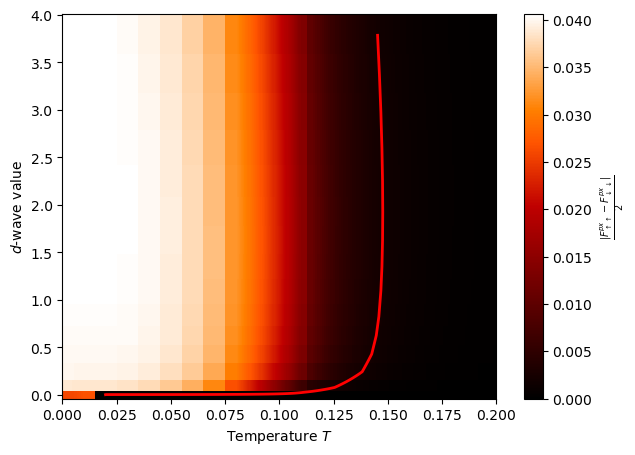

In [ ]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
]) * V_arr

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total

V_num = len(V_arr)
temps_num = len(temps)
dwave_arr = np.r_[0,dwave_arr]


df = np.load('./data/DFP_hx_mult.npz')

temps_df = np.vstack([temps_df_np, df["temps"].reshape(V_num, temps_num)])[0]
F0 = np.vstack([F0_np, df["F0"].reshape(V_num, temps_num)])
F_swave = np.vstack([F_swave_np, df["F_swave"].reshape(V_num, temps_num)])
F_dwave = np.vstack([F_dwave_np, df["F_dwave"].reshape(V_num, temps_num)])
F_px = np.vstack([F_px_np, df["F_px"].reshape(V_num, temps_num)])
F_py = np.vstack([F_py_np, df["F_py"].reshape(V_num, temps_num)])
Fuu_px = np.vstack([Fuu_px_np, df["Fuu_px"].reshape(V_num, temps_num)])
Fuu_py = np.vstack([Fuu_py_np, df["Fuu_py"].reshape(V_num, temps_num)])
Fdd_px = np.vstack([Fdd_px_np, df["Fdd_px"].reshape(V_num, temps_num)])
Fdd_py = np.vstack([Fdd_py_np, df["Fdd_py"].reshape(V_num, temps_num)])

import numpy as np
import matplotlib.pyplot as plt

# intensity
I = np.abs(Fuu_px - Fdd_px) / 2

# threshold
threshold = 0.05 * I.max()
threshold2 = 0.01 * I.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

# red contour line
ax.contour(
    temps_df,
    dwave_arr,
    I,
    levels=[threshold],
    colors='red',
    linewidths=2
)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [ ]:
I = np.abs(Fuu_px - Fdd_px) / 2
threshold = 0.05 * I.max()

Tc_direct = []
dwave_valid = []

for i, dw in enumerate(dwave_arr):
    row = I[i, :]
    above = row >= threshold
    crossings = np.where(np.diff(above.astype(int)))[0]
    
    if len(crossings) > 0:
        Tc_direct.append(temps[crossings[0]])
        dwave_valid.append(dw)

Tc_d = np.array(Tc_direct)
dwave_d = np.array(dwave_valid)
Tc_d = Tc_d#/np.max(Tc_s)

(14, 240) (14,) (14, 240)


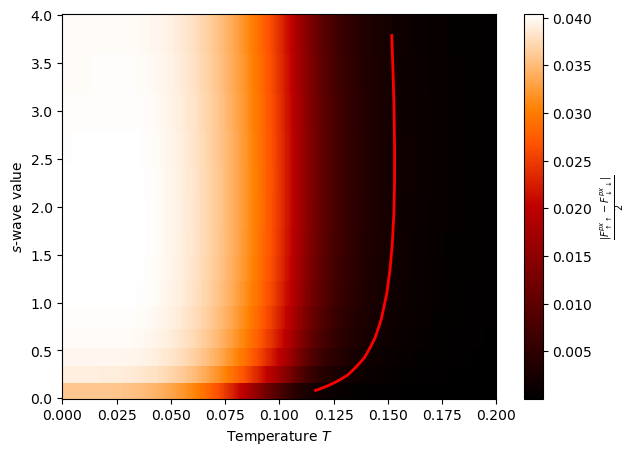

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
U_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

swave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
]) * U_arr

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.100 + 1e-12, 0.001),
    np.arange(0.1005, 0.1400 + 1e-12, 0.0005),
    np.arange(0.141, 0.200 + 1e-12, 0.001),
])  # 240 temps total

U_num = len(U_arr)
temps_num = len(temps)
df_s = np.load('./data/SFP_hx_mult.npz')
temps_df_s = df_s["temps"].reshape(U_num, temps_num)
F0_s = df_s["F0"].reshape(U_num, temps_num)
F_swave_s = df_s["F_swave"].reshape((U_num, temps_num))
F_dwave_s = df_s["F_dwave"].reshape((U_num, temps_num))
F_px_s = df_s["F_px"].reshape((U_num, temps_num))
F_py_s = df_s["F_py"].reshape((U_num, temps_num))
Fuu_px_s = df_s["Fuu_px"].reshape((U_num, temps_num))
Fuu_py_s = df_s["Fuu_py"].reshape((U_num, temps_num))
Fdd_px_s = df_s["Fdd_px"].reshape((U_num, temps_num))
Fdd_py_s = df_s["Fdd_py"].reshape((U_num, temps_num))
import numpy as np
import matplotlib.pyplot as plt

# intensity
I = np.abs(Fuu_px_s - Fdd_px_s) / 2

# threshold
threshold = 0.05 * I.max()
threshold2 = 0.01 * I.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    swave_arr,
    I,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df_s.shape, swave_arr.shape, I.shape)
# red contour line
ax.contour(
    temps,
    swave_arr,
    I,
    levels=[threshold],
    colors='red',
    linewidths=2
)
ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$s$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()


In [ ]:
I = np.abs(Fuu_px_s - Fdd_px_s) / 2
threshold = 0.05 * I.max()

Tc_direct = []
dwave_valid = []

for i, dw in enumerate(dwave_arr):
    row = I[i, :]
    above = row >= threshold
    crossings = np.where(np.diff(above.astype(int)))[0]
    
    if len(crossings) > 0:
        Tc_direct.append(temps[crossings[0]])
        dwave_valid.append(dw)

Tc_s = np.array(Tc_direct)
dwave_s = np.array(dwave_valid)
Tc_s = Tc_s#/np.max(Tc_s)

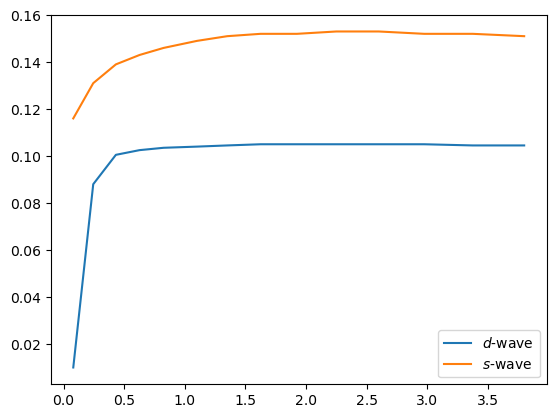

In [ ]:
plt.figure(1)
plt.plot(swave_arr, Tc_d, label=r"$d$-wave")
plt.plot(swave_arr, Tc_s, label=r"$s$-wave")
plt.legend()

In [25]:
df_dfp = np.load('./data/DFPFD.npz')
converged=df_dfp['converged']
temps = df_dfp["temps"]
dwave = df_dfp["F_dwave"]
px = df_dfp["Fuu_px"]
py = (df_dfp["Fuu_py"] + df_dfp["Fdd_py"]) / 2
print(np.where(converged==False))

(array([25]),)


(0.0, 0.2)

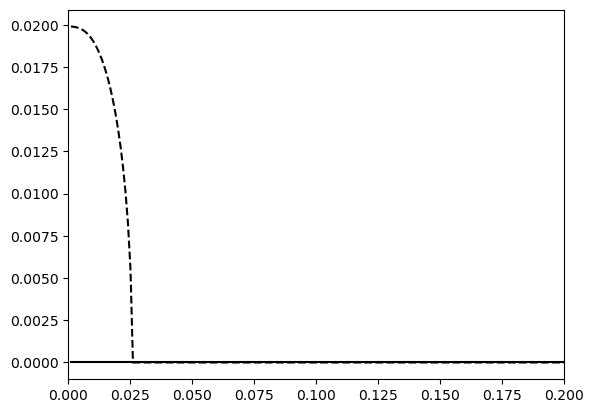

In [26]:
plt.figure()
plt.plot(temps_dfp, np.abs(px_dfp), label=r"$p_x$", color='black')
plt.plot(temps_dfp, np.imag(py_dfp), "--", label=r"$p_y$", color='black')
plt.xlim(0,0.20)

In [21]:
# 27368.510879387348

In [22]:

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.200 + 1e-12, 0.001),
])  # 163 temps total

print(len(temps))

163
